# Which model captures *my* biology?

**What you'll learn.** Embed the same cells with several single-cell foundation
models, then score the embeddings with two metric families embpy wraps — **scIB**
and **cell-eval** — and plot the results. The point is not a leaderboard for its
own sake; it is that "which model is best" becomes a measurement on your data
instead of an opinion about model size.

The two families answer different questions, which is why both are here:

| Family | Question | Needs |
| --- | --- | --- |
| **scIB** | does the embedding preserve known structure? | one AnnData + a label |
| **cell-eval** | do two conditions agree in this space? | a *pair* of AnnData |

A model can win one and lose the other, and that disagreement is informative
rather than noise.

## Requirements

This notebook needs single-cell foundation models, and those do not share one
resolvable environment with the metrics. That is worth stating up front, because
`pip install embpy[helical]` alone will not get you here.

`helical` (scGPT, Geneformer, UCE) declares `numpy>=2.1.3,<2.3` and
`transformers<=4.51.3`. `arc-state` needs `transformers>=4.52.3`, and
`cell-eval` pulls `pdex`, which needs `numpy>=2.4.2`. Those constraints are
mutually unsatisfiable, so a resolver refuses the combination outright.

In practice the helical ceilings are stale rather than real -- the same was true
of the `esm` SDK's `transformers` pin. Installing it with `--no-deps` and
supplying its actual runtime dependencies works:

```bash
uv venv .venv-sc --python 3.13
uv pip install --python ./.venv-sc/bin/python \
    arc-state arc-stack scvi-tools scib scib-metrics "cell-eval>=0.7.2" scanpy
uv pip install --python ./.venv-sc/bin/python -e .          # embpy, with its deps
uv pip install --python ./.venv-sc/bin/python --no-deps helical
uv pip install --python ./.venv-sc/bin/python \
    "datasets==3.6.0" einops sentencepiece biopython catalogue \
    pybiomart requests-cache
uv pip install --python ./.venv-sc/bin/python "transformers==4.57.6"
```

Four details in there are load-bearing, and each cost a debugging round:

* **`--no-deps helical`** is the whole trick. Installed normally it either
  refuses to resolve or drags numpy back below 2.3.
* **`datasets==3.6.0` exactly.** helical pins it, and it means it: on
  `datasets` 5.x Geneformer dies with
  `'Column' object has no attribute 'device'`.
* **`transformers==4.57.6`, not 5.x.** embpy's core pins
  `huggingface-hub<1.0.0`, which lacks the `is_offline_mode` that
  transformers 5 imports.
* **`-e .` without `--no-deps`.** embpy's own core (rdkit, sklearn, …) is
  light and has no torch in it; skipping it leaves you with import errors that
  look like model problems.
* **`scib` *and* `scib-metrics`.** They are different packages and
  `tl.compute_scib_metrics` imports the first one. Installing only
  `scib-metrics` gets you `DependencyError: 'scib' is required for scIB
  embedding metrics`.

Skipped on purpose:

* **`stack`** installs and loads, then fails inside arc-stack's own h5ad
  reader (`Could not find gene names in the file`) even with `gene_name_col`
  supplied. Upstream, not embpy.
* **`uce`** works but is 1280-dim and slow on CPU; add it if you have a GPU.

In [1]:
import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

from embpy import BioEmbedder, tl

## The data, and why it is shaped this way

Two requirements pull in opposite directions. The count-based models
(scGPT, Geneformer) want **raw counts** and real gene symbols; scIB wants a
**curated label** to score against. scanpy's `pbmc3k` gives the first and
`pbmc3k_processed` the second, so take the intersection: raw counts from one,
`louvain` cell types from the other.

Using a label somebody else assigned matters. Clustering the embeddings and then
scoring against those clusters would measure self-consistency, not biology.

In [2]:
raw = sc.datasets.pbmc3k()
raw.var_names_make_unique()
processed = sc.datasets.pbmc3k_processed()

shared = raw.obs_names.intersection(processed.obs_names)
adata = raw[shared].copy()
adata.obs["cell_type"] = processed[shared].obs["louvain"].astype(str).values

# 400 cells keeps a CPU run to minutes. The metrics are noisier at this size --
# say so rather than quoting three decimal places as if they were stable.
sc.pp.subsample(adata, n_obs=400, random_state=0)

print(f"{adata.n_obs} cells x {adata.n_vars} genes, "
      f"X max = {adata.X.max():.0f} (raw counts)")
display(adata.obs["cell_type"].value_counts().to_frame("n_cells"))

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

400 cells x 32738 genes, X max = 258 (raw counts)


,n_cells
cell_type,
CD4 T cells,189
CD14+ Monocytes,72
B cells,58
CD8 T cells,39
NK cells,18
FCGR3A+ Monocytes,16
Dendritic cells,6
Megakaryocytes,2


## Embed with several models

`embed_cells` takes a list and writes one `.obsm` entry per model, handling the
model-aware preprocessing itself. `pca` is the baseline that has to be beaten:
if a 600-million-parameter transformer cannot separate cell types better than
truncated SVD, its extra capacity bought you nothing here.

Budget for `state` before you run this. It has no local weights by default, so
the first call fetches the SE-600M release -- about 12 GB, cached afterwards --
and on CPU it took ~24 minutes for 400 cells against seconds for the others.
Pass `model_kwargs={"state": {"checkpoint": "/path/to.ckpt"}}` to use a copy you
already have, and give it a GPU if you have one.

In [3]:
ROSTER = ["pca", "scvi", "scgpt", "geneformer_v2_12L", "state"]

embedder = BioEmbedder(device="auto")
adata = embedder.embed_cells(
    adata, models=ROSTER, preprocessing="auto", batch_size=8, copy=True,
)

/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.venv-sc/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/ ...
INFO: GPU available: False, used: False


INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False


INFO: TPU available: False, using: 0 TPU cores


INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

Encoding: 100%|██████████| 9/9 [18:12<00:00, 121.44s/it]

INFO:root:  -> stored in .obsm['X_state'], shape (400, 2058)


2026-08-21 12:12:44,351 - INFO:root:  -> stored in .obsm['X_state'], shape (400, 2058)


INFO:root:embed_cells complete: 5 models, 400 cells


2026-08-21 12:12:44,441 - INFO:root:embed_cells complete: 5 models, 400 cells


> **`embed_cells` does not raise when a model fails.** It catches the exception
> per model, records it under
> `.uns["embpy_cell_embeddings"][model]["error"]`, and returns a normal
> AnnData. That is the right call -- one broken backend should not cost you
> three working ones -- but it means *the return value cannot tell you whether
> it worked*. A missing `.obsm` key is the only symptom, and it looks like
> nothing at all.
>
> So read the metadata rather than trusting the object. This cell is not
> defensive boilerplate; it is the difference between four embeddings and two.

In [4]:
meta = adata.uns["embpy_cell_embeddings"]

rows, EMBEDDINGS = [], []
for model in ROSTER:
    entry = meta.get(model, {})
    if "error" in entry:
        rows.append({"model": model, "status": "FAILED", "dim": None,
                     "detail": entry["error"][:60]})
        continue
    key = entry["obsm_key"]
    EMBEDDINGS.append(key)
    rows.append({"model": model, "status": "ok",
                 "dim": adata.obsm[key].shape[1], "detail": key})

display(pd.DataFrame(rows).set_index("model"))
print(f"scoring {len(EMBEDDINGS)}/{len(ROSTER)} embeddings: {EMBEDDINGS}")

,status,dim,detail
model,,,
pca,ok,50,X_pca
scvi,ok,30,X_scvi
scgpt,ok,512,X_scgpt
geneformer_v2_12L,ok,512,X_geneformer_v2_12L
state,ok,2058,X_state


scoring 5/5 embeddings: ['X_pca', 'X_scvi', 'X_scgpt', 'X_geneformer_v2_12L', 'X_state']


## 1. scIB: does the embedding preserve known structure?

`tl.compute_scib_metrics` wraps `scib-metrics`. Given the embeddings and a label
it returns one row per embedding: NMI and ARI for label agreement after
clustering, `asw_label` for silhouette separation, `clisi` for local label
consistency, and `bio_conservation` as their mean.

Pass `batch_key=` as well and you additionally get the batch-removal half
(`asw_batch`, `graph_conn`, `ilisi`, `kbet`) plus a `total`. This panel has no
batch covariate, so those columns are absent -- which is the honest outcome,
not a gap to paper over.

In [5]:
SCIB = tl.compute_scib_metrics(
    adata, embedding_keys=EMBEDDINGS, label_key="cell_type",
)
display(SCIB.round(3))

INFO:embpy.tl.scib_metrics:Scoring embedding 'X_pca' with scIB ...


2026-08-21 12:12:56,231 - INFO:embpy.tl.scib_metrics:Scoring embedding 'X_pca' with scIB ...


In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)



2026-08-21 12:13:37,584 - WARNING:py.warnings:/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.venv-sc/lib/python3.13/site-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)



Cluster for scib_cluster_0.1 with leiden


...

In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)



2026-08-21 12:13:55,268 - WARNING:py.warnings:/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.venv-sc/lib/python3.13/site-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)



2026-08-21 12:13:55,427 - WARNING:embpy.tl.scib_metrics:scIB metric 'isolated_label_asw' failed for 'X_state' ('[nan] not in index'); reporting NaN.


Cluster for scib_cluster_2.0 with leiden


,nmi,ari,asw_label,isolated_label_asw,clisi,bio_conservation,batch_correction,total
X_geneformer_v2_12L,0.831,0.861,0.604,NaN,0.986,0.820,NaN,0.820
X_state,0.811,0.824,0.508,NaN,0.938,0.770,NaN,0.770
X_pca,0.774,0.804,0.522,NaN,0.909,0.752,NaN,0.752
X_scvi,0.750,0.715,0.549,NaN,0.951,0.741,NaN,0.741
X_scgpt,0.738,0.639,0.561,NaN,0.979,0.729,NaN,0.729


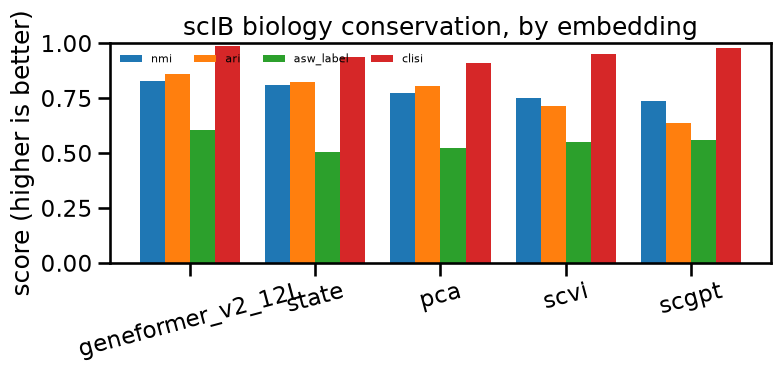

In [6]:
# Plot the biology-conservation components side by side. Every scIB metric here
# is on [0, 1] and higher is better, so one shared axis is legitimate.
components = [c for c in ("nmi", "ari", "asw_label", "clisi") if c in SCIB.columns]
labels = [k.replace("X_", "") for k in SCIB.index]

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.8 / len(components)
positions = np.arange(len(SCIB))
for i, metric in enumerate(components):
    ax.bar(positions + i * width, SCIB[metric].values, width, label=metric)

ax.set_xticks(positions + width * (len(components) - 1) / 2)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("score (higher is better)")
ax.set_ylim(0, 1)
ax.set_title("scIB biology conservation, by embedding")
ax.legend(frameon=False, ncol=len(components), fontsize=8)
fig.tight_layout()
plt.show()

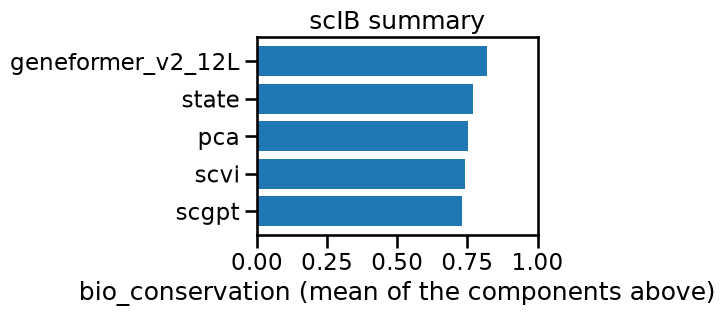

best on this panel: X_geneformer_v2_12L (0.820)
pca baseline:       0.752


In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ranked = SCIB["bio_conservation"].sort_values()
ax.barh([k.replace("X_", "") for k in ranked.index], ranked.values,
        color="tab:blue")
ax.set_xlabel("bio_conservation (mean of the components above)")
ax.set_xlim(0, 1)
ax.set_title("scIB summary")
fig.tight_layout()
plt.show()

print(f"best on this panel: {ranked.index[-1]} ({ranked.iloc[-1]:.3f})")
print(f"pca baseline:       {SCIB.loc['X_pca', 'bio_conservation']:.3f}"
      if "X_pca" in SCIB.index else "")

Read that against the baseline rather than in isolation. A foundation model that
lands near `pca` has told you something useful about *this* dataset: the
structure being scored is recoverable linearly, so the extra capacity is not
being asked for anything.

Two caveats worth carrying:

* **400 cells is small.** NMI and ARI both depend on a clustering step, and at
  this size the clustering is unstable. Treat the ordering as indicative and
  re-run at full size before quoting a number.
* **`louvain` labels are themselves a clustering.** They came from the
  processed PBMC pipeline, so they are not ground truth -- they are a
  well-established convention. That is better than labels you invented here,
  and still not the same as biology.

## 2. cell-eval: do two conditions agree in this space?

cell-eval is built for perturbation prediction, so it scores a **(predicted,
real) pair** rather than a single object -- both must carry the same
perturbation labels and share a control level. Its 17 differential-expression
metrics work over gene identities and therefore cannot apply to an embedding at
all. Its 10 `ANNDATA_PAIR` metrics can: each takes an `embed_key` and runs on
`.obsm` instead of `.X`.

One metric, `discrimination_score_l1`, hardcodes `embed_key = None` upstream
and therefore always reads `.X`. It is skipped rather than left to put an
expression-space number in an embedding-space table.

There is no perturbation here, so the pair has to be constructed, and what it
means depends entirely on how. Splitting each cell type in half and calling one
half "predicted" measures **how well an embedding places two independent samples
of the same population together** -- an agreement ceiling, and a fair thing to
compare embeddings on. It is emphatically *not* a model's prediction accuracy.

In [8]:
rng = np.random.default_rng(0)

# cell-eval requires the two objects to carry *identical* label sets -- it
# raises `Perturbation mismatch` otherwise. A plain random half-split fails
# that: with eight types over 400 cells the rarest can land entirely on one
# side. So split within each type, and drop types too small to appear on both.
counts = adata.obs["cell_type"].value_counts()
usable = counts[counts >= 4].index          # >= 2 cells per side
dropped = sorted(set(counts.index) - set(usable))

paired = adata[adata.obs["cell_type"].isin(usable)].copy()
is_pred = np.zeros(paired.n_obs, dtype=bool)
for cell_type in usable:
    idx = np.flatnonzero(paired.obs["cell_type"].values == cell_type)
    rng.shuffle(idx)
    is_pred[idx[: len(idx) // 2]] = True

real, pred = paired[~is_pred].copy(), paired[is_pred].copy()

# The most abundant type is the reference every other one is compared against.
CONTROL = paired.obs["cell_type"].value_counts().idxmax()
for part in (real, pred):
    part.obs["perturbation"] = part.obs["cell_type"].astype(str)

print(f"real {real.n_obs} cells | pred {pred.n_obs} cells")
print(f"control level: {CONTROL!r}")
if dropped:
    print(f"dropped (too few cells to appear on both sides): {dropped}")
assert set(real.obs["perturbation"]) == set(pred.obs["perturbation"])
print(f"{len(usable)} labels present on both sides")

real 200 cells | pred 198 cells
control level: 'CD4 T cells'
dropped (too few cells to appear on both sides): ['Megakaryocytes']
7 labels present on both sides


In [9]:
from cell_eval import MetricType, metrics_registry

# `profile="anndata"` runs every ANNDATA_PAIR metric, so configure every one of
# them. Naming only a few would leave the rest scoring `.X` while the table
# implied they scored the embedding -- a mixed-space result that looks uniform.
ALL_PAIR = set(metrics_registry.list_metrics(MetricType.ANNDATA_PAIR))

# discrimination_score_l1 ignores embed_key upstream (it hardcodes
# `embed_key = None`), so it cannot be made to read `.obsm`. Skip it rather
# than let one expression-space column sit in an embedding-space table.
UNCONFIGURABLE = {"discrimination_score_l1"}
CE_METRICS = sorted(ALL_PAIR - UNCONFIGURABLE)
print(f"scoring on the embedding: {len(CE_METRICS)} metrics")
print(f"skipped (ignores embed_key): {sorted(UNCONFIGURABLE)}")

frames = {}
for key in EMBEDDINGS:
    try:
        frames[key] = tl.run_cell_eval(
            pred, real,
            control_pert=CONTROL, pert_col="perturbation",
            profile="anndata", skip_de=True,
            metric_configs={m: {"embed_key": key} for m in CE_METRICS},
            skip_metrics=sorted(UNCONFIGURABLE),
        )
    except Exception as exc:
        print(f"{key}: {type(exc).__name__}: {str(exc)[:110]}")

print("scored:", list(frames))
if frames:
    display(next(iter(frames.values())).head(3).round(3))

  pl.enable_string_cache()



2026-08-21 12:14:06,177 - WARNING:py.warnings:/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.venv-sc/lib/python3.13/site-packages/cell_eval/_evaluator.py:119: DeprecationWarning: the string cache has been replaced by pl.Categories
  pl.enable_string_cache()



INFO:cell_eval.utils:Data appears to be integer counts (no decimal values detected)


2026-08-21 12:14:06,185 - INFO:cell_eval.utils:Data appears to be integer counts (no decimal values detected)


INFO:cell_eval._evaluator:Discovered integer data for real. Converting to norm-log.


...

2026-08-21 12:14:11,917 - INFO:embpy.tl.metrics:cell-eval finished (profile='anndata'): 6 perturbation rows, 9 aggregate rows.


INFO:embpy.tl.pipeline:cell-eval complete (profile='anndata'): 6 perturbations evaluated.


2026-08-21 12:14:11,918 - INFO:embpy.tl.pipeline:cell-eval complete (profile='anndata'): 6 perturbations evaluated.


scored: ['X_pca', 'X_scvi', 'X_scgpt', 'X_geneformer_v2_12L', 'X_state']


,perturbation,pearson_delta,mse,mae,mse_delta,mae_delta,discrimination_score_l2,discrimination_score_cosine,pearson_edistance,clustering_agreement
0,B cells,0.854,1.160,0.920,1.190,0.927,1.0,1.0,0.95,1.0
1,CD14+ Monocytes,0.931,0.585,0.589,0.767,0.660,1.0,1.0,0.95,1.0
2,CD8 T cells,0.827,0.712,0.624,0.676,0.589,1.0,1.0,0.95,1.0


In [10]:
# One frame per embedding, one row per perturbation. Average over
# perturbations to get a single number per embedding per metric. The frame's
# exact columns depend on the cell-eval version, so take what is numeric and
# present rather than assuming a fixed set.
if frames:
    summary = {}
    for key, frame in frames.items():
        numeric = frame.select_dtypes("number")
        summary[key.replace("X_", "")] = numeric.mean(numeric_only=True)
    CELL_EVAL = pd.DataFrame(summary).T
    display(CELL_EVAL.round(3))
else:
    CELL_EVAL = pd.DataFrame()
    print("no cell-eval results to summarise")

,pearson_delta,mse,mae,mse_delta,mae_delta,discrimination_score_l2,discrimination_score_cosine,pearson_edistance,clustering_agreement
pca,0.866,1.483,0.905,1.576,0.937,1.000,1.0,0.950,1.0
scvi,0.942,0.122,0.247,0.136,0.267,1.000,1.0,0.953,1.0
scgpt,0.954,0.000,0.002,0.000,0.002,1.000,1.0,0.991,1.0
geneformer_v2_12L,0.961,0.004,0.045,0.004,0.048,1.000,1.0,0.982,1.0
state,0.705,0.000,0.006,0.000,0.007,0.972,1.0,0.999,1.0


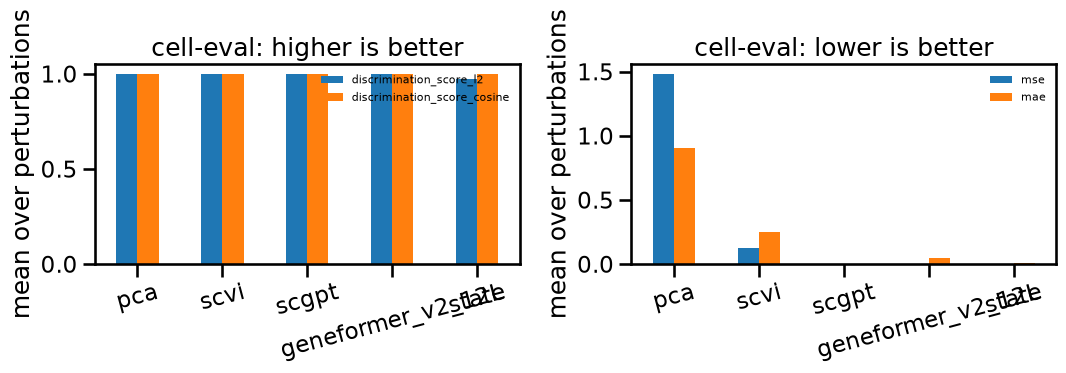

In [11]:
if not CELL_EVAL.empty:
    # Discrimination scores and errors point in opposite directions, so they get
    # separate panels rather than a shared axis that would flatter one of them.
    higher = [c for c in CELL_EVAL.columns if "discrimination" in c]
    lower = [c for c in CELL_EVAL.columns if c in ("mae", "mse")]
    panels = [(higher, "higher is better"), (lower, "lower is better")]
    panels = [(cols, title) for cols, title in panels if cols]

    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 3.8))
    axes = np.atleast_1d(axes)
    for ax, (cols, title) in zip(axes, panels):
        CELL_EVAL[cols].plot.bar(ax=ax, rot=15, legend=True)
        ax.set_title(f"cell-eval: {title}")
        ax.set_ylabel("mean over perturbations")
        ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    plt.show()

The discrimination scores are the ones to read. They ask whether the embedding
puts a held-out sample of a cell type closer to that same type than to any
other -- which is exactly the property you want from a representation you intend
to compare conditions in.

`mae` and `mse` are computed in embedding space here, so their absolute values
are not comparable *across* embeddings of different dimensionality and scale.
Use them within one embedding, or normalise first.

## Which metric answers which question

| You want to know | Use | On |
| --- | --- | --- |
| does it preserve known cell types? | `tl.compute_scib_metrics` | one AnnData + label |
| does it remove a batch effect? | same, with `batch_key=` | one AnnData + label + batch |
| do two conditions agree in this space? | `tl.run_cell_eval`, `profile="anndata"` | a (pred, real) pair |
| does a predicted expression matrix match? | `tl.run_cell_eval`, `profile="full"` | a pair, over genes |
| does it predict a measured property? | `tl.benchmark_embeddings` | AnnData + a numeric target |

`benchmark_embeddings` is the right tool when you have a real measurement to
predict -- an IC50, a dependency score, a viability readout. It is deliberately
not used above, because this notebook has no such measurement, and training a
probe against a column of noise produces a leaderboard that ranks nothing.

## Takeaway

- **Score against labels you did not choose.** Clustering an embedding and then
  scoring it against those clusters measures self-consistency.
- **Beat the baseline or explain why not.** `pca` is cheap and often close;
  a foundation model that ties with it has answered a question about your data.
- **Read the failures.** `embed_cells` records per-model errors in `.uns` and
  returns normally, so a silently absent `.obsm` key is the only clue.
- **Say what the pair is.** cell-eval's numbers mean whatever your (pred, real)
  construction means. Here it is two halves of one dataset, which is an
  agreement ceiling, not prediction accuracy.

**Next:** [What else embpy knows about your entities](05_annotate_entities.ipynb)
for the annotation layer, or
[Validating single-cell embeddings with scIB](scib_validation.ipynb) for the
scIB half at full dataset size.